# RGMx Product Segmentation

**Task**:

Segment products into groups with similar sales dynamics and promotional responsiveness.

**Summary**:

After cleaning, 353 products tracked weekly across 6 retailers for 3 years. Each product is described by 10 behavioural features (no size, no revenue — behaviour only).

K-Means gives 3 groups: Promo leaders (58 products, 41% of revenue — heavily promoted, and promo weeks clearly outsell quiet weeks), Steady core (234, 49% — drilled down into big steady sellers / promo-dabbling middle / micro-distribution tail), Shrinking shelf (61, 10% — losing distribution week after week). Stability on resampling: 0.96 against a pass mark of 0.6.

Rejected `total_volume` as an input: it is inconsistent within products (section 1).

## Index

1. **Data Exploration** — column checks, data quality, cleaning, the distribution confound
2. **Feature Engineering** — 10 features, correlations
3. **Methodology** — preparation, how many groups (with the scores), which algorithm
4. **Modelling** — 3 groups: profiles, names, composition, suggested actions
5. **Output Analysis** — trust checks, market drift, compete / sell-together map, retailer lens
6. **Final Results & Next Steps**

## Assumptions

| # | Decision | Why |
|---|---|---|
| 1 | Price = `total_sales / total_units` (per pack) | Only definition independent of the volume column |
| 2 | Rows under 10p/pack dropped | ~2p median price, ~0% shelf presence, 0.06% of revenue. Sensitivity-tested at 50p (section 5) |
| 3 | Duplicate (product, retailer, week) rows merged: sum sales, max ACV | Barcode records of the same product — never a different pack size |
| 4 | Products with < 13 weeks excluded | Too little history to measure trend or season |
| 5 | Size and revenue descriptive only | Groups should be behaviour, not big-vs-small |
| 6 | Currency is assumed GBP. | The file doesn't say; `UK_DISHCARE` suggests it. Only affects labels. |

## Flow

```
raw (84,550 rows) -> clean (3 rules) -> 63,834 rows / 353 products
-> 10 features -> clip / scale / PCA -> K-Means (K=3)
-> group profiles + names + actions -> trust checks -> cross-price map
```

## 0. Setup

Libraries: `pandas`/`numpy` (tabular), `scikit-learn` (scaling, PCA, K-Means, validation
metrics), `scipy` (p-values in the cross-price screen), `networkx` (the link map),
`matplotlib`/`seaborn` (figures). All standard, preinstalled in Colab, nothing pinned.
Scalability: everything is groupby-based and linear in rows; clustering runs on products, not
transactions; the only quadratic piece (the pair screen) is capped at the top 40 of one
subcategory. Detail in `docs/PRODUCTION.md`.

In [1]:
## Optional — only needed in Google Colab. Running locally? Skip.
try:
    from google.colab import drive
    import os
    drive.mount('/content/drive')
    folder = '/content/drive/MyDrive/Product-Segmentation'   # <- edit if your folder differs
    if os.path.isdir(folder):
        os.chdir(folder)
        print('Working directory:', os.getcwd())
    else:
        print(f'{folder} not found — upload ECON_POS.csv to the session instead.')
except ImportError:
    print('Not in Colab — nothing to do here.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/Product-Segmentation


In [2]:
# all imports in one place
import os, glob, warnings, itertools, calendar
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import networkx as nx
from scipy import stats
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, silhouette_samples, calinski_harabasz_score,
                             adjusted_rand_score, adjusted_mutual_info_score)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
RNG = 42
K = 3

if not Path("config.yaml").exists() and Path("../config.yaml").exists():
    os.chdir("..")   # notebook lives in notebooks/ -- work from the project root

DATA_CANDIDATES = ["data/ECON_POS.csv", "ECON_POS.csv", "../data/ECON_POS.csv"]
DATA_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
assert DATA_PATH is not None, "Put ECON_POS.csv next to this notebook or in a data/ folder."

IMG_DIR, OUT_DIR = "docs/img", "output"
os.makedirs(IMG_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)
for old in glob.glob(f"{IMG_DIR}/*.png") + glob.glob(f"{OUT_DIR}/*.csv"):
    os.remove(old)

written = []
def save_and_show(fig, name):
    path = f"{IMG_DIR}/{name}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    written.append(path); plt.show()

def save_table(df, name):
    path = f"{OUT_DIR}/{name}.csv"
    df.to_csv(path, index=False); written.append(path)

raw = pd.read_csv(DATA_PATH, low_memory=False)
raw["period_id"] = pd.to_datetime(raw["period_id"], format="%m/%d/%Y")
print(f"{len(raw):,} rows | {raw.rgm_ppg.nunique()} products | {raw.retailer_nm.nunique()} retailers | "
      f"{raw.period_id.nunique()} weeks ({raw.period_id.min().date()} to {raw.period_id.max().date()})")

84,550 rows | 366 products | 6 retailers | 157 weeks (2022-12-03 to 2025-11-29)


## 1. Data Exploration

One row = one product (`rgm_ppg`) at one retailer in one week. `acv_pct` = share of the market
(store-size weighted) stocking the product that week — called **shelf presence** below. The promo
ACV columns say in what share of the market it was on each promo type.

In [3]:
print("category:", raw.category.unique().tolist(), "| cmu:", raw.cmu.unique().tolist(),
      "| channel:", raw.channel_nm.unique().tolist())
display(raw.groupby("subcategory_nm")
        .agg(rows=("rgm_ppg", "size"), products=("rgm_ppg", "nunique"),
             revenue_m=("total_sales", lambda s: s.sum() / 1e6))
        .sort_values("rows", ascending=False).round(2))

category: ['DISHWASHER PRODUCTS'] | cmu: ['UK_DISHCARE'] | channel: ['Supermarkets']


,rows,products,revenue_m
subcategory_nm,,,
DETERGENT,65026,309,734.92
CLEANER,7181,19,57.54
RINSE AID,5879,21,66.18
SALT,4326,9,55.74
FRESHENER,1749,7,3.81
GLASS PROTECTOR,389,1,0.62


**Is a product one physical thing?** If one `rgm_ppg` mixed pack sizes, price per pack would
move with the mix. Check:

In [4]:
per_ppg = raw.groupby("rgm_ppg")[["product_unit_size", "uom", "product_pack_count",
                                  "subcategory_nm", "brand_nm"]].nunique()
print("products where the attribute takes exactly ONE value (of", raw.rgm_ppg.nunique(), "):")
print((per_ppg == 1).sum().to_string())

products where the attribute takes exactly ONE value (of 366 ):
product_unit_size     366
uom                   366
product_pack_count    366
subcategory_nm        366
brand_nm              366


Every product is one size, one format, one brand. Price per pack is clean.

**Promo columns.** Three claims to verify: the four promo-type ACVs roughly sum to `any_promo_acv_pct` (overlap allowed), promo units ≤ total units, promo money ≤ total money.

In [5]:
promo_parts = ["acv_tpr_only", "feature_and_display_acv_pct",
               "feature_without_display_acv_pct", "display_without_feature_acv_pct"]
part_sum = raw[promo_parts].sum(axis=1)
print(f"sum of parts vs any_promo_acv_pct: within 1pt in "
      f"{np.isclose(part_sum, raw.any_promo_acv_pct, atol=1.0).mean():.1%}, "
      f"corr {part_sum.corr(raw.any_promo_acv_pct):.3f}; rows where raw sum > 100: {(part_sum > 100).sum():,}")
print(f"any_promo_units <= total_units: {(raw.any_promo_units <= raw.total_units).mean():.2%}")
print(f"any_promo_amt   <= total_sales: {(raw.any_promo_amt <= raw.total_sales + 1e-6).mean():.2%}")

sum of parts vs any_promo_acv_pct: within 1pt in 98.7%, corr 0.993; rows where raw sum > 100: 36
any_promo_units <= total_units: 100.00%
any_promo_amt   <= total_sales: 99.98%


All hold. The four type columns overlap (raw sum can exceed 100), so only the deduplicated
`any_promo_acv_pct` is used from here on.

**The volume column.** It is said tha `total_volume` is doses. Then volume ÷ units would be constant per product - a 42-pack is 42 doses every week. Check:

In [6]:
ok = (raw.total_units > 0) & ((raw.total_sales / raw.total_units) >= 0.10)
vpu = (raw.total_volume / raw.total_units)[ok]
cv = (raw[ok].assign(vpu=vpu).groupby("rgm_ppg").vpu
      .agg(lambda s: s.std() / s.mean() if s.mean() > 0 else np.nan))
print(f"volume-per-unit within one product: median CV = {cv.median():.2f}  (doses would give ~0)")

big = raw[ok & (raw.subcategory_nm == "DETERGENT")].rgm_ppg.value_counts().idxmax()
ex = raw[ok & (raw.rgm_ppg == big)]
print(f"\nexample, one {ex.product_unit_size.iloc[0]}{ex.uom.iloc[0]} product across retailers:")
print(ex.groupby("retailer_nm").apply(lambda g: (g.total_volume / g.total_units).median())
      .round(1).rename("median vol/unit").to_string())

volume-per-unit within one product: median CV = 0.53  (doses would give ~0)

example, one 42CT product across retailers:
retailer_nm
HASH_4456A3C8    30.5
HASH_7B58EB7D    36.2
HASH_86AFA19D    30.1
HASH_E5E16C6D    25.8
HASH_EA52C362    33.1
HASH_FE494EA4    28.2


Not consistent — swings within one fixed-size product and differs by retailer.

`total_volume` is not used anywhere. Stated `product_unit_size × product_pack_count` is used
for size-comparable prices instead.

`product_id` does not seem to be the right, it will not be used as the key.

In [7]:
ids = raw.product_id.astype(str)
worst = raw.groupby("product_id").rgm_ppg.nunique().sort_values(ascending=False)
print(f"{ids.nunique()} distinct product_id values for {raw.rgm_ppg.nunique()} products; "
f"{worst.index[0]} id maps to {worst.iloc[0]} products.")

43 distinct product_id values for 366 products; 5.06E+12 id maps to 171 products.


### 1.1 Data quality — junk-priced rows

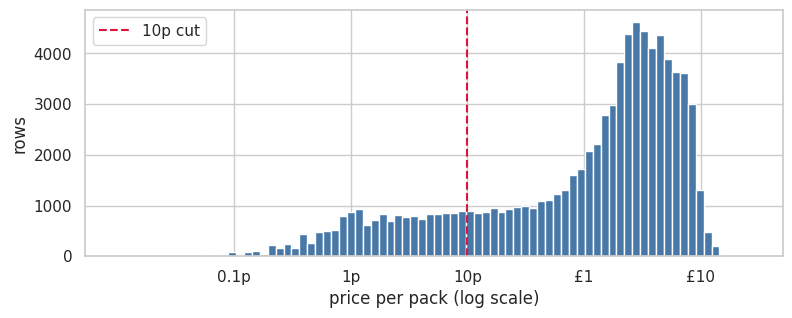

,rows,median price,median shelf presence,share of revenue
price < 10p,16395,2.1p,0.1538,0.055%
price >= 10p,68155,£2.55,28.1832,99.945%


In [8]:
raw["price_per_pack"] = raw.total_sales / raw.total_units.replace(0, np.nan)
cheap = raw.price_per_pack < 0.10

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(np.log10(raw.price_per_pack.dropna()), bins=80, color="#4878a8")
ax.axvline(np.log10(0.10), color="crimson", ls="--", label="10p cut")
ticks = [0.001, 0.01, 0.10, 1, 10]
ax.set_xticks(np.log10(ticks)); ax.set_xticklabels(["0.1p", "1p", "10p", "£1", "£10"])
ax.set_xlabel("price per pack (log scale)"); ax.set_ylabel("rows"); ax.legend()
save_and_show(fig, "price_distribution")

display(pd.DataFrame({
    "rows": [cheap.sum(), (~cheap).sum()],
    "median price": [f"{raw.price_per_pack[cheap].median()*100:.1f}p",
                     f"£{raw.price_per_pack[~cheap].median():.2f}"],
    "median shelf presence": [raw.acv_pct[cheap].median(), raw.acv_pct[~cheap].median()],
    "share of revenue": [f"{raw.total_sales[cheap].sum() / raw.total_sales.sum():.3%}",
                         f"{raw.total_sales[~cheap].sum() / raw.total_sales.sum():.3%}"],
}, index=["price < 10p", "price >= 10p"]))

No clean valley in the histogram — the cut is justified by the rows' signature, not the
shape: ~2p median price, ~0% shelf presence, 0.06% of revenue. Feed noise, not trading. The exact
threshold is debatable, so section 5 re-runs everything with a 50p cut. What these rows are is an open question.

### 1.2 Data quality — duplicate rows

In [9]:
keys = ["rgm_ppg", "retailer_nm", "period_id"]
dup_mask = raw.duplicated(keys, keep=False)
groups_d = raw[dup_mask].groupby(keys)
print(f"rows in duplicates: {dup_mask.sum():,} ({dup_mask.mean():.1%}) across {groups_d.ngroups:,} keys")

differs = (raw[dup_mask].groupby(keys).nunique() > 1).mean().sort_values(ascending=False)
print("\nshare of duplicate keys where the column differs:")
print(differs[differs > 0.01].round(2).to_string())
print("\nnever differ:", [c for c in ["product_unit_size", "uom", "product_pack_count",
      "subcategory_nm", "brand_nm"] if differs.get(c, 0) == 0])
print(f"keys where every row has units > 0: "
      f"{groups_d.total_units.apply(lambda s: (s > 0).all()).mean():.0%} -> all real sales")

rows in duplicates: 13,734 (16.2%) across 6,439 keys

share of duplicate keys where the column differs:
acv_pct                            1.00
price_per_pack                     1.00
total_sales                        1.00
total_units                        1.00
total_volume                       1.00
any_promo_amt                      0.73
any_promo_units                    0.73
any_promo_eq                       0.73
any_promo_acv_pct                  0.73
product_id                         0.71
acv_tpr_only                       0.69
attribute_2                        0.37
feature_without_display_acv_pct    0.27
feature_and_display_acv_pct        0.17
attribute_5                        0.17
display_without_feature_acv_pct    0.13
attribute_4                        0.10
attribute_7                        0.03

never differ: ['product_unit_size', 'uom', 'product_pack_count', 'subcategory_nm', 'brand_nm']
keys where every row has units > 0: 100% -> all real sales


Different `product_id`s (and packaging flags), **never** a different pack size — barcode
variants of the same product, not sub-week data and not pack sizes. So: **sum** the sales
columns, **max** the ACV columns (the variants sit in largely the same stores).

### 1.3 Cleaning — three rules, applied once

In [10]:
SALES_COLS = ["total_units", "total_volume", "total_sales", "any_promo_units", "any_promo_amt"]
ACV_COLS = ["acv_pct", "any_promo_acv_pct", "acv_tpr_only", "feature_and_display_acv_pct",
            "feature_without_display_acv_pct", "display_without_feature_acv_pct"]

def clean(frame, price_floor=0.10, min_weeks=13):
    frame = frame.copy()
    frame["price_per_pack"] = frame.total_sales / frame.total_units.replace(0, np.nan)
    junk = (frame.price_per_pack < price_floor) | frame.price_per_pack.isna() | (frame.total_units <= 0)
    kept = frame[~junk]
    meta = kept.groupby("rgm_ppg")[["subcategory_nm", "brand_nm", "uom",
                                    "product_unit_size", "product_pack_count"]].first()
    merged = (kept.groupby(["rgm_ppg", "retailer_nm", "period_id"], as_index=False)
                  .agg({**{c: "sum" for c in SALES_COLS}, **{c: "max" for c in ACV_COLS}})
                  .merge(meta, on="rgm_ppg"))
    merged["price_per_pack"] = merged.total_sales / merged.total_units
    weeks = merged.groupby("rgm_ppg").period_id.nunique()
    too_new = weeks[weeks < min_weeks].index
    return merged[~merged.rgm_ppg.isin(too_new)].reset_index(drop=True), int(junk.sum()), len(too_new)

sales, n_junk, n_too_new = clean(raw)
print(f"dropped {n_junk:,} junk rows; excluded {n_too_new} products under 13 weeks")
print(f"working table: {len(sales):,} rows, {sales.rgm_ppg.nunique()} products, "
      f"{sales.period_id.nunique()} weeks")

dropped 16,395 junk rows; excluded 13 products under 13 weeks
working table: 63,834 rows, 353 products, 157 weeks


### 1.4 Distribution vs demand — the one confound to get right

The loudest driver of unit sales is how many stores stock the product, not how much shoppers like it:

In [11]:
prod_means = sales.groupby("rgm_ppg").agg(units=("total_units", "mean"), shelf=("acv_pct", "mean"))
r = np.corrcoef(np.log(prod_means.shelf.clip(lower=0.1)), np.log(prod_means.units.clip(lower=1)))[0, 1]
print(f"correlation of log(shelf presence) with log(units): {r:.2f}")

correlation of log(shelf presence) with log(units): 0.56


How concentrated is the portfolio? Standard Pareto check on the cleaned data:

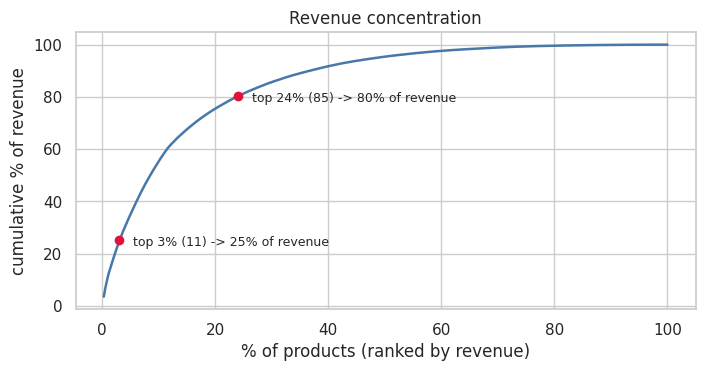

top 3% of products (11) carry 25% of revenue; 80% of revenue sits in the top 84 products (24%)
the bottom half of the portfolio carries 4.6%


In [12]:
rev = sales.groupby("rgm_ppg").total_sales.sum().sort_values(ascending=False)
cum = rev.cumsum() / rev.sum()
n = len(rev)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(np.arange(1, n + 1) / n * 100, cum.values * 100, color="#4878a8", lw=1.8)
for share in [0.03, 0.24]:
    k = max(1, int(round(share * n)))
    ax.plot([share * 100], [cum.iloc[k - 1] * 100], "o", color="crimson")
    ax.annotate(f"top {share:.0%} ({k}) -> {cum.iloc[k-1]:.0%} of revenue",
                (share * 100, cum.iloc[k - 1] * 100), textcoords="offset points",
                xytext=(10, -4), fontsize=9)
ax.set_xlabel("% of products (ranked by revenue)"); ax.set_ylabel("cumulative % of revenue")
ax.set_title("Revenue concentration")
save_and_show(fig, "pareto_revenue")

k80 = int((cum >= 0.80).values.argmax()) + 1
print(f"top 3% of products ({int(round(0.03*n))}) carry {cum.iloc[int(round(0.03*n))-1]:.0%} of revenue; "
      f"80% of revenue sits in the top {k80} products ({k80/n:.0%})")
print(f"the bottom half of the portfolio carries {1 - cum.iloc[n - n//2 - 1]:.1%}")

Steeper than the classic 80/20: **3% of products carry a quarter of revenue, 24% carry 80%**, and the bottom half of the portfolio carries under 5%. Two consequences for everything below: per-group treatment is worth more than per-product effort outside the head, and a long, thin tail exists that some group will have to own — section 4 finds it, and section 5.4 explains what it actually is.

### 1.5 Category backdrop — trend and seasonality

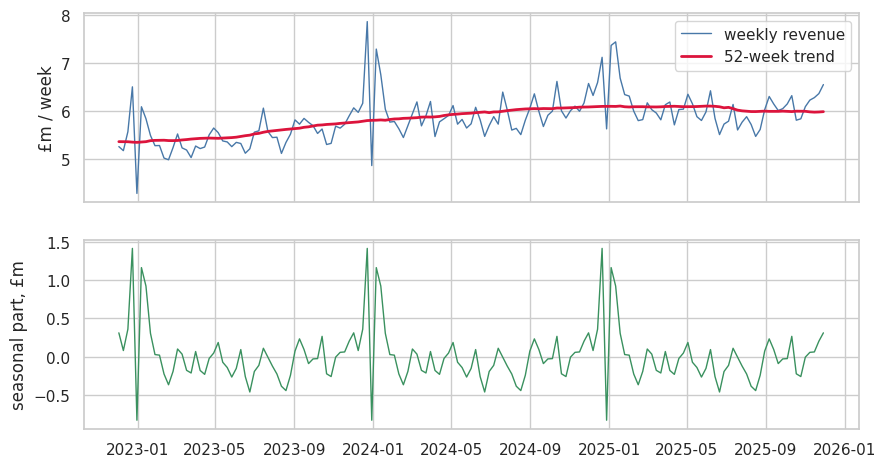

variance shares -- trend 27%, season 55%, leftover 13%
peak January (+0.60 £m/wk), trough August (-0.26), avg week 5.8 £m


In [13]:
cat = sales.groupby("period_id").total_sales.sum() / 1e6
trend = cat.rolling(52, center=True, min_periods=26).mean()
detrended = cat - trend
season = detrended.groupby(pd.Index(cat.index.isocalendar().week, name="woy")).transform("mean")
leftover = detrended - season

fig, axes = plt.subplots(2, 1, figsize=(10, 5.4), sharex=True)
axes[0].plot(cat.index, cat.values, color="#4878a8", lw=1, label="weekly revenue")
axes[0].plot(trend.index, trend.values, color="crimson", lw=2, label="52-week trend")
axes[0].set_ylabel("£m / week"); axes[0].legend()
axes[1].plot(season.index, season.values, color="#3a915f", lw=1)
axes[1].set_ylabel("seasonal part, £m")
save_and_show(fig, "category_decomposition")

v = cat.var()
monthly = season.groupby(cat.index.month).mean()
print(f"variance shares -- trend {trend.var()/v:.0%}, season {season.var()/v:.0%}, "
      f"leftover {leftover.var()/v:.0%}")
print(f"peak {calendar.month_name[monthly.idxmax()]} ({monthly.max():+.2f} £m/wk), "
      f"trough {calendar.month_name[monthly.idxmin()]} ({monthly.min():+.2f}), "
      f"avg week {cat.mean():.1f} £m")

Real annual rhythm (January peak, late-summer trough) on a slow trend. The per-product
seasonality feature in section 2 measures how much of this rhythm each product carries.

## 2. Feature Engineering

One row per product, 10 features, all mapped to a lever. Size and revenue stay descriptive.

| feature | measures | how | formula |
|---|---|---|---|
| `price_tier` | cheap vs premium for its kind | price per stated content, ranked within subcategory × uom | rank( avg_price / (unit_size × pack_count) ), 0–1 |
| `shelf_presence` | how widely stocked | mean ACV % | mean(acv_pct) |
| `shelf_trend` | gaining/losing stores | slope of weekly ACV, pts/week | slope of acv_pct over weeks |
| `bumpiness` | sales volatility | coefficient of variation of weekly units | std(units) / mean(units) |
| `price_moves` | price volatility | coefficient of variation of weekly price per pack | std(price) / mean(price) |
| `growth` | demand direction net of distribution | slope of log sales rate | slope of log(1 + units / smoothed shelf) |
| `seasonality` | repeating annual rhythm | share of detrended variance explained by the cycle (0–1) | 1 − var(wobble − yearly avg) / var(wobble) |
| `promo_activity` | how widely promoted | mean `any_promo_acv_pct` | mean(any_promo_acv_pct) |
| `promo_share` | revenue sold on deal | `any_promo_amt / total_sales` | Σ promo_amt / Σ sales |
| `promo_lift` | do promo weeks outsell quiet weeks | top-quartile vs bottom-quartile promo weeks, on the **detrended** sales rate | exp( median wobble, heavy weeks − median wobble, quiet weeks ) − 1 |

`wobble` is the log sales rate with the product's own linear trend removed — the same detrended series throughout.

`promo_lift` is detrended so a delisted product with late-life promos doesn't show a fake negative lift. It is a contrast, not a causal effect — promos are scheduled when demand is expected.

In [14]:
def weekly_view(g):
    """One product's weekly totals: units summed across retailers, shelf and promo averaged."""
    return (g.groupby("period_id")
             .agg(units=("total_units", "sum"), shelf=("acv_pct", "mean"),
                  promo=("any_promo_acv_pct", "mean")).sort_index())
def movement(g):
    w = weekly_view(g)
    out = {"growth": np.nan, "shelf_trend": np.nan, "seasonality": 0.0, "promo_lift": np.nan}
    if len(w) < 8: return out
    steady = w.shelf.rolling(9, min_periods=4, center=True).median().fillna(w.shelf)
    x = np.arange(len(w), dtype=float)
    log_rate = np.log1p((w.units / steady.clip(lower=1)).values)
    slope, intercept = np.polyfit(x, log_rate, 1)
    out["growth"] = slope
    out["shelf_trend"] = np.polyfit(x, w.shelf.values, 1)[0]
    wobble = log_rate - (slope * x + intercept)
    cycle = 52 if len(w) >= 104 else 13
    if len(w) >= 2 * cycle and np.var(wobble) > 0:
        cyc = pd.Series(wobble).groupby(np.arange(len(w)) % cycle).transform("mean")
        out["seasonality"] = max(0.0, 1 - np.var(wobble - cyc.values) / np.var(wobble))
    if len(w) >= 26 and w.promo.std() > 0:
        heavy = (w.promo >= w.promo.quantile(0.75)).values
        quiet = (w.promo <= w.promo.quantile(0.25)).values
        if heavy.sum() >= 4 and quiet.sum() >= 4:
            out["promo_lift"] = float(np.expm1(np.median(wobble[heavy]) - np.median(wobble[quiet])))
    return out

def build_features(sales):
    prod = (sales.groupby(["rgm_ppg", "subcategory_nm", "brand_nm", "uom"], as_index=False)
            .agg(avg_units=("total_units", "mean"), unit_swing=("total_units", "std"),
                 avg_price=("price_per_pack", "mean"), price_swing=("price_per_pack", "std"),
                 total_revenue=("total_sales", "sum"), shelf_presence=("acv_pct", "mean"),
                 promo_revenue=("any_promo_amt", "sum"), promo_activity=("any_promo_acv_pct", "mean"),
                 pack_size=("product_unit_size", "first"), pack_count=("product_pack_count", "first"),
                 n_weeks=("period_id", "nunique")))
    prod["bumpiness"] = prod.unit_swing / prod.avg_units
    prod["price_moves"] = prod.price_swing / prod.avg_price
    prod["promo_share"] = prod.promo_revenue / prod.total_revenue
    content = (pd.to_numeric(prod.pack_size, errors="coerce")
               * pd.to_numeric(prod.pack_count, errors="coerce"))
    prod["price_tier"] = (prod.assign(ppc=prod.avg_price / content)
                          .groupby(["subcategory_nm", "uom"]).ppc.rank(pct=True))
    moves = pd.DataFrame([{"rgm_ppg": p, **movement(g)} for p, g in sales.groupby("rgm_ppg")])
    return prod.merge(moves, on="rgm_ppg")

features = build_features(sales)
FEATURES = ["price_tier", "shelf_presence", "bumpiness", "price_moves", "growth",
            "seasonality", "shelf_trend", "promo_activity", "promo_share", "promo_lift"]
print(f"{len(features)} products x {len(FEATURES)} features; blanks:",
      features[FEATURES].isna().sum()[lambda s: s > 0].to_dict(),
      "(too little promo variation to measure lift; median-filled at prep)")

353 products x 10 features; blanks: {'promo_lift': 35} (too little promo variation to measure lift; median-filled at prep)



### 2.1 How the features relate

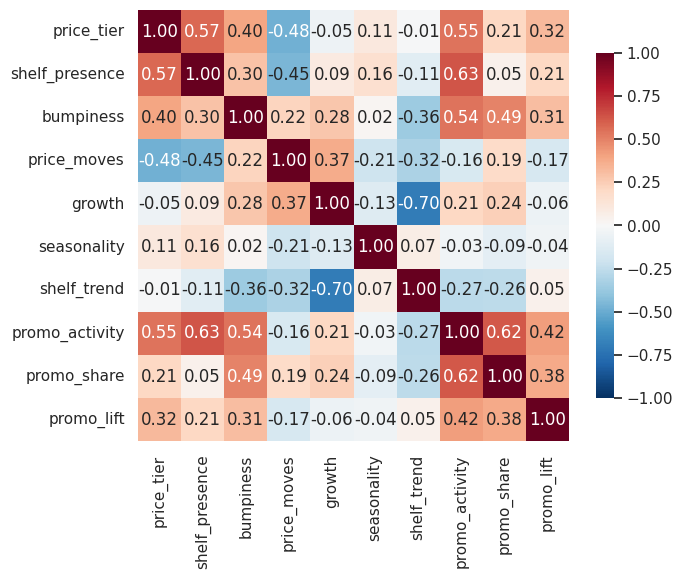

pairs beyond |0.5|: [('price_tier', 'shelf_presence', np.float64(0.57)), ('price_tier', 'promo_activity', np.float64(0.55)), ('shelf_presence', 'promo_activity', np.float64(0.63)), ('bumpiness', 'promo_activity', np.float64(0.54)), ('growth', 'shelf_trend', np.float64(-0.7)), ('promo_activity', 'promo_share', np.float64(0.62))]


In [15]:
corr = features[FEATURES].corr()
fig, ax = plt.subplots(figsize=(7, 5.6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"shrink": 0.8}, ax=ax)
save_and_show(fig, "feature_correlations")
print("pairs beyond |0.5|:", [(a, b, round(corr.loc[a, b], 2))
      for a, b in itertools.combinations(FEATURES, 2) if abs(corr.loc[a, b]) > 0.5])

Several features overlap by construction (promo activity × promo share; shelf × promo).
That's the argument for PCA before clustering: fold correlated features into independent
directions so nothing is counted twice.

## 3. Methodology

**Preparation**: clip 1%/99% → fill blank lifts with the median → RobustScaler → PCA at 90%
variance.

In [16]:
def prep(f):
    r = f[FEATURES].clip(f[FEATURES].quantile(0.01), f[FEATURES].quantile(0.99), axis=1)
    r = r.fillna(r.median())
    scaled = RobustScaler().fit_transform(r)
    return scaled, PCA(n_components=0.90, random_state=RNG).fit_transform(scaled)

scaled, squashed = prep(features)
print(f"PCA: {len(FEATURES)} features -> {squashed.shape[1]} components (90% of variance)")

PCA: 10 features -> 5 components (90% of variance)


### 3.1 How many groups

,inertia,silhouette,calinski_harabasz,biggest_group_%
K,,,,
2,2089.236,0.417,161.243,81.870
3,1445.543,0.407,194.116,66.289
4,1174.012,0.378,185.793,58.357
5,1031.436,0.298,170.178,41.926
6,928.950,0.268,158.384,32.861
7,828.017,0.274,154.678,32.861
8,757.810,0.276,149.012,31.445
9,718.327,0.218,139.517,20.397
10,669.475,0.225,135.459,20.397


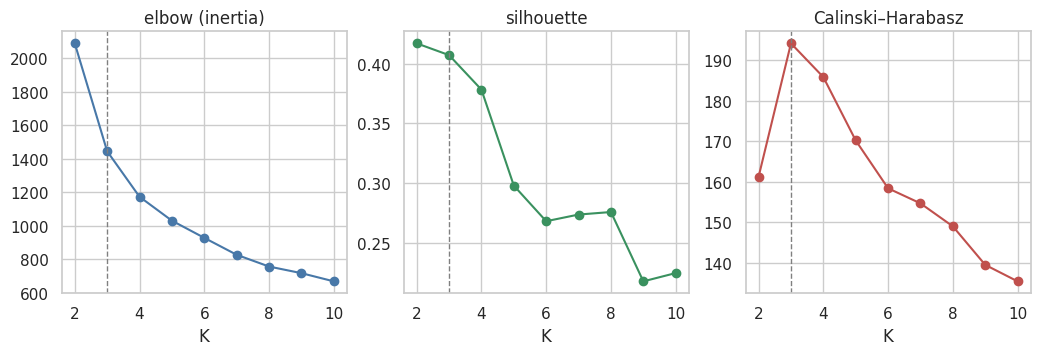

In [17]:
scan = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=20, random_state=RNG).fit(squashed)
    scan.append({"K": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(squashed, km.labels_),
                 "calinski_harabasz": calinski_harabasz_score(squashed, km.labels_),
                 "biggest_group_%": pd.Series(km.labels_).value_counts(normalize=True).max() * 100})
scan = pd.DataFrame(scan).set_index("K")
display(scan.round(3))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))
axes[0].plot(scan.index, scan.inertia, "o-", color="#4878a8")
axes[0].set_title("elbow (inertia)"); axes[0].set_xlabel("K")
axes[1].plot(scan.index, scan.silhouette, "o-", color="#3a915f")
axes[1].set_title("silhouette"); axes[1].set_xlabel("K")
axes[2].plot(scan.index, scan.calinski_harabasz, "o-", color="#c0504d")
axes[2].set_title("Calinski–Harabasz"); axes[2].set_xlabel("K")
for ax in axes: ax.axvline(3, color="grey", ls="--", lw=1)
save_and_show(fig, "k_selection_scores")

Rule, set before looking: K starts at 3 — K=2 puts 82% of products in one bucket
("widely stocked" vs "the rest"), technically clean and commercially useless — and among K ≥ 3
the best combined rank of the two scores wins. That is **K = 3** (silhouette 0.407, CH 194;
both curves fall away after it, and the elbow offers nothing sharper). The big group this
produces gets a drill-down in section 4, which keeps the map coarse where it is reliable and
fine where action needs it.

Hyperparameter check — is there anything left to tune? KMeans has few knobs beyond K:
initialisation, restarts, seed, algorithm variant, convergence rules. Sweep them all:

In [18]:
base = KMeans(n_clusters=K, n_init=20, random_state=RNG).fit_predict(squashed)
tune = []

# axis 1: initialisation method x number of restarts x seed
for init in ["k-means++", "random"]:
    for n_init in [1, 5, 20, 50]:
        for seed in [0, 42, 123]:
            km = KMeans(n_clusters=K, init=init, n_init=n_init, random_state=seed).fit(squashed)
            tune.append({"init": init, "n_init": n_init, "seed": seed,
                         "inertia": round(km.inertia_, 1),
                         "silhouette": round(silhouette_score(squashed, km.labels_), 3),
                         "same groups (ARI vs chosen)": round(adjusted_rand_score(base, km.labels_), 3)})

# axis 2: algorithm variant + tight convergence rules
for algo in ["lloyd", "elkan"]:
    km = KMeans(n_clusters=K, n_init=20, random_state=RNG, algorithm=algo,
                tol=1e-6, max_iter=1000).fit(squashed)
    tune.append({"init": f"k-means++ / {algo}, tol=1e-6", "n_init": 20, "seed": RNG,
                 "inertia": round(km.inertia_, 1),
                 "silhouette": round(silhouette_score(squashed, km.labels_), 3),
                 "same groups (ARI vs chosen)": round(adjusted_rand_score(base, km.labels_), 3)})
print(f"converged in {km.n_iter_} iterations (limit 1000, tol 1e-6) — the stopping rules never bind")

# axis 3: the scale-out variant
mb = MiniBatchKMeans(n_clusters=K, n_init=20, random_state=RNG).fit(squashed)
tune.append({"init": "minibatch (scale-out variant)", "n_init": 20, "seed": RNG,
             "inertia": round(mb.inertia_, 1),
             "silhouette": round(silhouette_score(squashed, mb.labels_), 3),
             "same groups (ARI vs chosen)": round(adjusted_rand_score(mb.labels_, base), 3)})

tune = pd.DataFrame(tune)
display(tune.groupby(["init", "n_init"]).agg(inertia=("inertia", "max"),
        silhouette=("silhouette", "max"),
        agreement=("same groups (ARI vs chosen)", "min")))
print(f"worst agreement with the chosen solution across all settings: "
      f"{tune['same groups (ARI vs chosen)'].min():.3f}")

converged in 11 iterations (limit 1000, tol 1e-6) — the stopping rules never bind


inertia  silhouette  agreement
init                          n_init                                
k-means++                     1        1445.5       0.407      1.000
                              5        1445.5       0.407      1.000
                              20       1445.5       0.407      1.000
                              50       1445.5       0.407      1.000
k-means++ / elkan, tol=1e-6   20       1445.5       0.407      1.000
k-means++ / lloyd, tol=1e-6   20       1445.5       0.407      1.000
minibatch (scale-out variant) 20       1447.0       0.406      0.972
random                        1        1445.5       0.407      1.000
                              5        1445.5       0.407      1.000
                              20       1445.5       0.407      1.000
                              50       1445.5       0.407      1.000

worst agreement with the chosen solution across all settings: 0.972


**Parameters chosen**: `n_clusters=3` (the only parameter that matters), `init='k-means++'`, `n_init=20`, `random_state=42`, everything else at library defaults. Not because tuning found them best because tuning showed *nothing is
better than anything else*: the three groups are a property of the data, not of the settings.

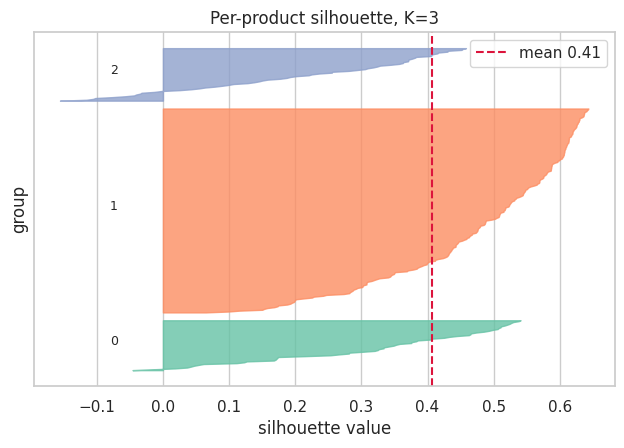

products with negative silhouette: 4% (sit between groups — expect them to migrate between refreshes)


In [19]:
km = KMeans(n_clusters=K, n_init=20, random_state=RNG).fit(squashed)
features["group"] = km.labels_

# per-product silhouette diagram at K=6
sil_vals = silhouette_samples(squashed, km.labels_)
fig, ax = plt.subplots(figsize=(7.5, 4.6))
y0, palette = 10, sns.color_palette("Set2", K)
for g in range(K):
    vals = np.sort(sil_vals[km.labels_ == g])
    ax.fill_betweenx(np.arange(y0, y0 + len(vals)), 0, vals, color=palette[g], alpha=0.8)
    ax.text(-0.08, y0 + len(vals) / 2, str(g), fontsize=9)
    y0 += len(vals) + 8
ax.axvline(sil_vals.mean(), color="crimson", ls="--", label=f"mean {sil_vals.mean():.2f}")
ax.set_xlabel("silhouette value"); ax.set_yticks([]); ax.set_ylabel("group")
ax.set_title("Per-product silhouette, K=3"); ax.legend()
save_and_show(fig, "silhouette_diagram")
print(f"products with negative silhouette: {(sil_vals < 0).mean():.0%} "
      "(sit between groups — expect them to migrate between refreshes)")

## 4. Modelling — the three groups

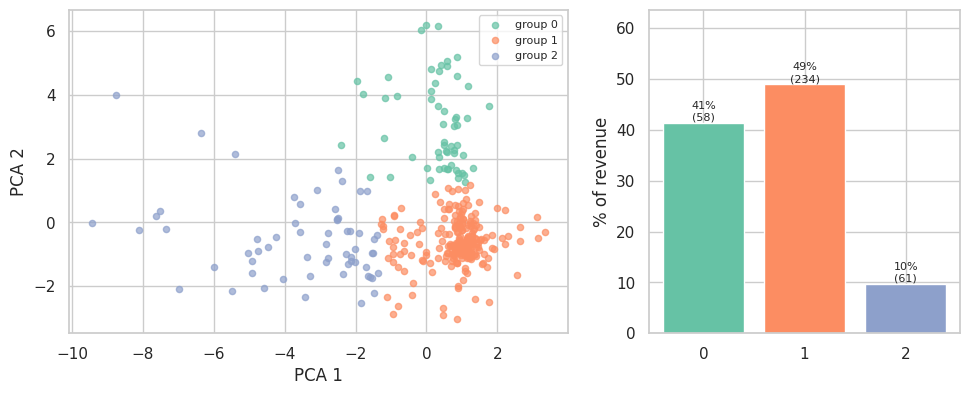

In [20]:
pc = PCA(n_components=2, random_state=RNG).fit_transform(scaled)
rev = features.groupby("group").total_revenue.sum() / features.total_revenue.sum() * 100
sizes = features.group.value_counts().sort_index()
palette = sns.color_palette("Set2", K)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios": [1.6, 1]})
for g in range(K):
    m = features.group.values == g
    axes[0].scatter(pc[m, 0], pc[m, 1], s=20, alpha=0.7, color=palette[g], label=f"group {g}")
axes[0].set_xlabel("PCA 1"); axes[0].set_ylabel("PCA 2"); axes[0].legend(fontsize=8)
axes[1].bar([str(g) for g in rev.index], rev.values, color=palette)
for i, (g, v) in enumerate(rev.items()):
    axes[1].text(i, v + 0.5, f"{v:.0f}%\n({sizes[g]})", ha="center", fontsize=8)
axes[1].set_ylabel("% of revenue"); axes[1].set_ylim(0, rev.max() * 1.3)
save_and_show(fig, "clusters_overview")

Names come from rules on the profile, not from me, so they survive re-runs:

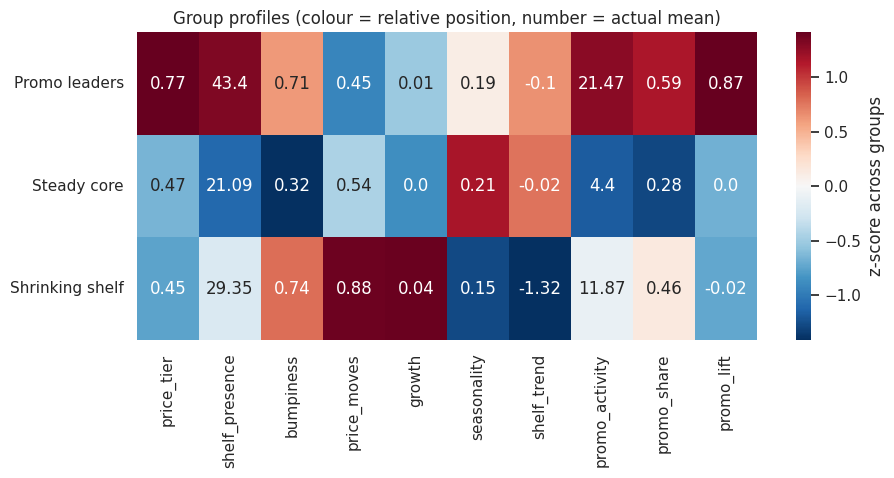

,products,revenue_pct
group_name,,
Steady core,234,48.9
Promo leaders,58,41.4
Shrinking shelf,61,9.7


In [21]:
profile = features.groupby("group")[FEATURES].mean()
z = (profile - profile.mean()) / profile.std(ddof=0)

def name_group(g):
    r = z.loc[g]
    if r.shelf_trend <= -0.8:    return "Shrinking shelf"
    if r.promo_activity >= 0.8:  return "Promo leaders"
    return "Steady core"

names = {g: name_group(g) for g in profile.index}
used = {}
for g in list(names):
    used[names[g]] = used.get(names[g], 0) + 1
    if used[names[g]] > 1: names[g] = f"{names[g]} {used[names[g]]}"
features["group_name"] = features.group.map(names)

fig, ax = plt.subplots(figsize=(10, 2.2 + 0.6 * K))
sns.heatmap(z.rename(index=names), annot=profile.round(2).values, fmt="",
            cmap="RdBu_r", center=0, cbar_kws={"label": "z-score across groups"}, ax=ax)
ax.set_title("Group profiles (colour = relative position, number = actual mean)"); ax.set_ylabel("")
save_and_show(fig, "group_profiles")

summary = (features.groupby("group_name")
           .agg(products=("rgm_ppg", "size"),
                revenue_pct=("total_revenue", lambda s: 100 * s.sum() / features.total_revenue.sum()))
           .sort_values("revenue_pct", ascending=False).round(1))
display(summary)

What each group is (figures from the profile above):

- **Promo leaders** — premium for their kind (tier 0.77), stocked almost everywhere (43%
  ACV), ~60% of revenue on deal, and heaviest-promo weeks ≈ 1.9× quietest on the detrended
  rate. An association, not a measured effect — which is why the action is measurement.
- **Steady core** — modest shelf, little promo, flat. Too mixed for one lever: drill-down below.
- **Shrinking shelf** — losing >1 ACV pt/week; the rate where stocked holds up. A distribution
  question, not a demand one.

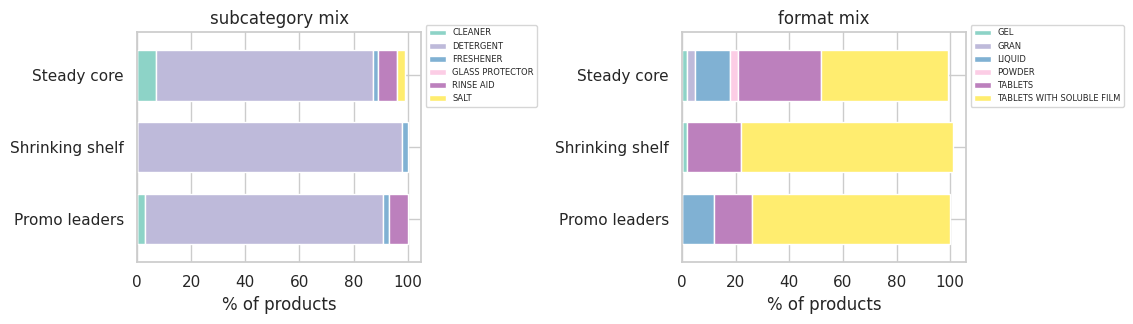

top attribute alignment with groups (adjusted mutual information):
attribute_9    0.06
attribute_7    0.06
attribute_1    0.05
ppg_attr6      0.05


In [22]:
# composition + attribute check: the model never saw these fields
features["format"] = features.rgm_ppg.map(raw.groupby("rgm_ppg").attribute_1.first())
subcat_mix = (pd.crosstab(features.group_name, features.subcategory_nm, normalize="index") * 100).round(0)
format_mix = (pd.crosstab(features.group_name, features.format, normalize="index") * 100).round(0)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
for ax, mix, title in [(axes[0], subcat_mix, "subcategory mix"), (axes[1], format_mix, "format mix")]:
    mix.plot(kind="barh", stacked=True, ax=ax, colormap="Set3", width=0.7)
    ax.set_title(title); ax.set_xlabel("% of products"); ax.set_ylabel("")
    ax.legend(fontsize=6, bbox_to_anchor=(1.0, 1.05))
fig.tight_layout()
save_and_show(fig, "group_composition")

attr_cols = [c for c in raw.columns if c.startswith(("attribute_", "ppg_attr"))]
attrs = raw.groupby("rgm_ppg")[attr_cols].first().reindex(features.rgm_ppg)
ami = pd.Series({c: adjusted_mutual_info_score(features.group_name, attrs[c].astype(str))
                 for c in attr_cols if attrs[c].nunique() > 1}).sort_values(ascending=False)
print("top attribute alignment with groups (adjusted mutual information):")
print(ami.head(4).round(2).to_string())

The clustering saw no catalogue fields, so alignments are discovered, not assumed — and no
attribute aligns strongly (AMI ≈ 0.05–0.1): the groups capture behaviour the catalogue doesn't
record.

**Suggested action per group.** Gate, set before profiling: ≥ 3% of products and ≥ 0.8 z on a
defining feature. All six qualify:

In [23]:
ACTIONS = {
    "Promo leaders": ("Optimise the promo calendar",
                          "Promo weeks clearly outsell quiet weeks"),
    "Steady core": ("No single action",
                    "Too big and too mixed for one lever"),
    "Shrinking shelf": ("Review product",
                        "Investigate shelf loss"),
}
sugg = summary.copy()
sugg["action"] = [ACTIONS.get(n, ("review", ""))[0] for n in sugg.index]
sugg["why"] = [ACTIONS.get(n, ("", ""))[1] for n in sugg.index]
display(sugg)
save_table(features[["rgm_ppg", "subcategory_nm", "format", "brand_nm", "uom", "pack_size",
                     "pack_count", "total_revenue", "group", "group_name"] + FEATURES].round(4),
           "product_groups")
save_table(sugg.reset_index(), "suggestions")

,products,revenue_pct,action,why
group_name,,,,
Steady core,234,48.9,No single action,Too big and too mixed for one lever
Promo leaders,58,41.4,Optimise the promo calendar,Promo weeks clearly outsell quiet weeks
Shrinking shelf,61,9.7,Review product,Investigate shelf loss


**Inside the steady core** — the biggest group, split again for targeting:

In [24]:
big = features.group.value_counts().idxmax()
idx = np.where(features.group.values == big)[0]
best = (None, -1.0, None)
for n in range(2, 6):
    lab = KMeans(n_clusters=n, n_init=20, random_state=RNG).fit_predict(squashed[idx])
    sc = silhouette_score(squashed[idx], lab)
    if sc > best[1]: best = (n, sc, lab)
n_sub, sil_sub, sub_labels = best
print(f"'{names[big]}' ({len(idx)} products) splits into {n_sub} layers (silhouette {sil_sub:.2f})")
display(features.iloc[idx].assign(sub=sub_labels).groupby("sub")
        .agg(products=("rgm_ppg", "size"), shelf=("shelf_presence", "mean"),
             promo=("promo_activity", "mean"), bumpiness=("bumpiness", "mean"),
             revenue_m=("total_revenue", lambda s: s.sum() / 1e6)).round(2))
save_table(features.iloc[idx].assign(sub=sub_labels)[["rgm_ppg", "sub"]], "biggest_group_split")

'Steady core' (234 products) splits into 3 layers (silhouette 0.29)


,products,shelf,promo,bumpiness,revenue_m
sub,,,,,
0,86,42.70,6.37,0.35,343.63
1,33,30.49,12.28,0.54,59.72
2,115,2.22,0.67,0.24,45.30


Three layers: big steady sellers (the backbone), a promo seeking middle, and a
115-product micro-distribution tail (~2% ACV each).

### 4.1 Portfolio coverage — where the white spaces are

The brief asks where price tiers or formats may be insufficiently covered. Coverage grid,
format × price tier, with the honest caveat that an empty cell is only an *opportunity* if
consumer demand exists there — which needs consumer data this file doesn't have.

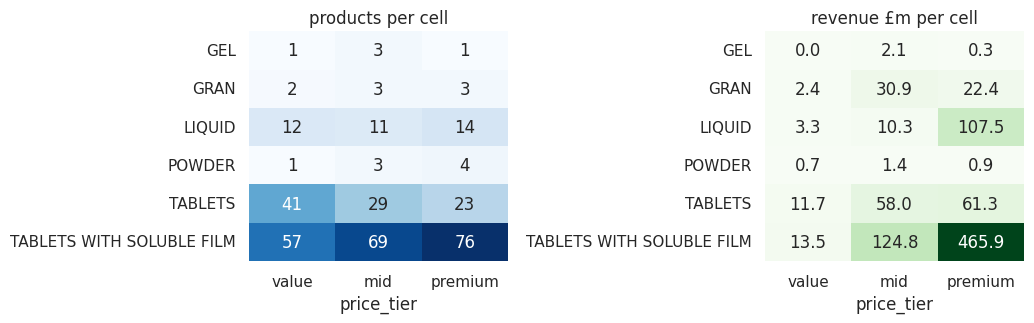

thin/empty cells (candidate white spaces, pending consumer validation): [('GEL', 'value'), ('GEL', 'premium'), ('GRAN', 'value'), ('POWDER', 'value')]


In [25]:
tier = pd.cut(features.price_tier, [0, 1/3, 2/3, 1], labels=["value", "mid", "premium"],
              include_lowest=True)
grid_n = features.pivot_table(index="format", columns=tier, values="rgm_ppg",
                              aggfunc="count", observed=False).fillna(0).astype(int)
grid_rev = (features.pivot_table(index="format", columns=tier, values="total_revenue",
                                 aggfunc="sum", observed=False).fillna(0) / 1e6).round(1)
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.4))
sns.heatmap(grid_n, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("products per cell"); axes[0].set_ylabel("")
sns.heatmap(grid_rev, annot=True, fmt=".1f", cmap="Greens", cbar=False, ax=axes[1])
axes[1].set_title("revenue £m per cell"); axes[1].set_ylabel("")
fig.tight_layout()
save_and_show(fig, "portfolio_coverage")
thin = [(f, t) for f in grid_n.index for t in grid_n.columns if grid_n.loc[f, t] <= 2]
print("thin/empty cells (candidate white spaces, pending consumer validation):", thin)

Which promo mechanics carry that activity? Descriptive mix only — mechanic *effectiveness* needs the baseline model (next steps):

In [26]:
mech = {"acv_tpr_only": "price cut only", "feature_and_display_acv_pct": "feature + display",
        "feature_without_display_acv_pct": "feature only",
        "display_without_feature_acv_pct": "display only"}
mech_mix = sales.groupby("rgm_ppg")[list(mech)].mean().rename(columns=mech)
mech_mix["group"] = mech_mix.index.map(features.set_index("rgm_ppg").group_name)
tab = mech_mix.groupby("group").mean().round(2)
tab["total promo ACV"] = tab.sum(axis=1).round(1)
display(tab)

,price cut only,feature + display,feature only,display only,total promo ACV
group,,,,,
Promo leaders,11.00,4.07,6.03,0.58,21.7
Shrinking shelf,7.00,1.72,2.79,0.49,12.0
Steady core,2.93,0.31,1.05,0.14,4.4


Plain price cuts carry half or more of all promo presence in every group; display-only is nearly unused. What is the ROI for feature/display?


## 5. Output Analysis

### 5.1 Should you trust cleaned data groups?


In [27]:
sales50, _, _ = clean(raw, price_floor=0.50)
feat50 = build_features(sales50)
_, squashed50 = prep(feat50)
lab50 = KMeans(n_clusters=K, n_init=20, random_state=RNG).fit_predict(squashed50)
common = np.intersect1d(features.rgm_ppg, feat50.rgm_ppg)
a = pd.Series(features.group.values, index=features.rgm_ppg).loc[common]
b = pd.Series(lab50, index=feat50.rgm_ppg).loc[common]
print(f"cleaning sensitivity (10p vs 50p cut): {len(common)} products, ARI {adjusted_rand_score(a, b):.2f}")

cleaning sensitivity (10p vs 50p cut): 331 products, ARI 0.68


The three cluster group shape survives a 5× harsher cleaning rule, but products near the group boundaries move around.

### 5.2 Is the model stable?

Same K, three methods. Judged on silhouette, **stability** (25 resamples at 80%), and balance:

In [28]:
def stability(fit_fn, X, tries=25, frac=0.8):
    rng = np.random.default_rng(RNG)
    full = fit_fn(X)
    return float(np.mean([adjusted_rand_score(full[idx], fit_fn(X[idx]))
                          for idx in (rng.choice(len(X), int(frac * len(X)), replace=False)
                                      for _ in range(tries))]))

methods = {
    "KMeans":       lambda X: KMeans(n_clusters=K, n_init=20, random_state=RNG).fit_predict(X),
    "Hierarchical": lambda X: AgglomerativeClustering(n_clusters=K).fit_predict(X),
    "GMM":          lambda X: GaussianMixture(n_components=K, n_init=5, random_state=RNG).fit_predict(X),
}
report = []
for name, fit_fn in methods.items():
    lab = fit_fn(squashed)
    shares = pd.Series(lab).value_counts(normalize=True)
    report.append({"method": name,
                   "silhouette": round(silhouette_score(squashed, lab), 2),
                   "stability": round(stability(fit_fn, squashed), 2),
                   "balance": round(float(-(shares * np.log(shares)).sum() / np.log(len(shares))), 2)})
display(pd.DataFrame(report).set_index("method"))

,silhouette,stability,balance
method,,,
KMeans,0.41,0.96,0.79
Hierarchical,0.38,0.44,0.58
GMM,0.18,0.80,0.99


K-Means passes the stability bar and is the easiest to re-run, explain and hand over — it's the one kept.

### 5.3 Did the market itself change over the 3 years?

mean |promo activity change|, first vs last 18 months: 6.2 ACV pts


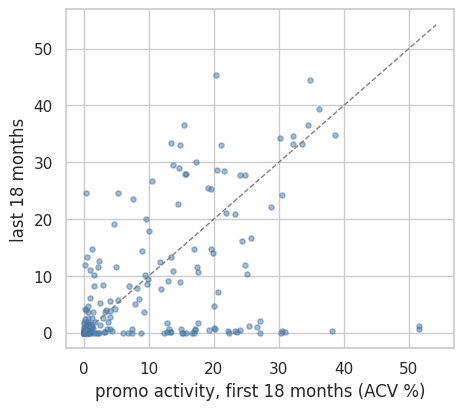

In [29]:
mid = sales.period_id.quantile(0.5)
p1 = sales[sales.period_id <= mid].groupby("rgm_ppg").any_promo_acv_pct.mean()
p2 = sales[sales.period_id > mid].groupby("rgm_ppg").any_promo_acv_pct.mean()
drift = pd.concat([p1, p2], axis=1, keys=["half1", "half2"]).dropna()
print(f"mean |promo activity change|, first vs last 18 months: "
      f"{(drift['half2'] - drift['half1']).abs().mean():.1f} ACV pts")
fig, ax = plt.subplots(figsize=(5, 4.4))
ax.scatter(drift["half1"], drift["half2"], s=14, alpha=0.5, color="#4878a8")
lim = max(drift.max()) * 1.05
ax.plot([0, lim], [0, lim], color="grey", ls="--", lw=1)
ax.set_xlabel("promo activity, first 18 months (ACV %)"); ax.set_ylabel("last 18 months")
save_and_show(fig, "promo_drift")

### 5.4 Which detergents compete, which sell together

One question per pair of the top-40 detergents: **when B's price goes up, does A sell more?**
If yes, shoppers switch between them — they compete (within one brand, that's cannibalisation).
If A sells *less*, they rise and fall together — they sell together (bought as a pair, or
sharing the same demand).

To make it a fair test, each check holds fixed the things we already know move A's sales:
A's own price, A's own promotions, how many shops stock A, A's trend, and how busy the whole
category was that week. 780 pairs get tested, so a link only counts if it clears a bar 780×
stricter than usual (p < 0.05/780) and the effect is meaningful (≥ 0.3).

This is a shortlist to test, not proof: the cheap decisive check is watching a linked
product's sales the next time its partner runs a deep promo. Nodes are labelled D01–D40 by
unit sales; the table below decodes them.

In [30]:
top_sub = sales.subcategory_nm.value_counts().idxmax()
weekly = (sales[sales.subcategory_nm == top_sub]
          .groupby(["rgm_ppg", "period_id"], as_index=False)
          .agg(units=("total_units", "sum"), revenue=("total_sales", "sum"),
               promo=("any_promo_acv_pct", "mean"), shelf=("acv_pct", "mean")))
weekly["price"] = weekly.revenue / weekly.units
category_week = weekly.groupby("period_id").units.sum()
top40 = weekly.groupby("rgm_ppg").units.sum().nlargest(40).index
series = {p: g.set_index("period_id") for p, g in weekly[weekly.rgm_ppg.isin(top40)].groupby("rgm_ppg")}

pairs = []
for a, b in itertools.combinations(top40, 2):
    t = series[a].join(series[b], rsuffix="_other", how="inner").dropna()
    if len(t) < 20: continue
    wk = np.asarray((t.index - t.index.min()).days, dtype=float) / 7.0
    cd = np.log(category_week.loc[t.index].values)
    X = np.column_stack([np.ones(len(t)), np.log(t.price_other), np.log(t.price),
                         t.promo / 100.0, np.log(t.shelf.clip(lower=0.5)),
                         wk - wk.mean(), cd - cd.mean()])
    beta, res, rank, _ = np.linalg.lstsq(X, np.log(t.units), rcond=None)
    dof = len(t) - rank
    if dof <= 0 or not res.size: continue
    se = np.sqrt(res[0] / dof * np.linalg.pinv(X.T @ X)[1, 1])
    if se == 0: continue
    pairs.append({"product_a": a, "product_b": b, "effect": beta[1],
                  "p": 2 * (1 - stats.t.cdf(abs(beta[1] / se), dof))})

links = pd.DataFrame(pairs).sort_values("p").reset_index(drop=True)
links = links[(links.p < 0.05 / len(links)) & (links.effect.abs() >= 0.30)]
print(f"{len(pairs)} pairs -> {len(links)} strict links "
      f"({(links.effect > 0).sum()} compete, {(links.effect < 0).sum()} sell together)")
save_table(links.round(4), "cross_price_links")

G = nx.Graph()
for _, r in links.iterrows():
    G.add_edge(r.product_a, r.product_b, weight=abs(r.effect), sign=np.sign(r.effect))

780 pairs -> 45 strict links (28 compete, 17 sell together)


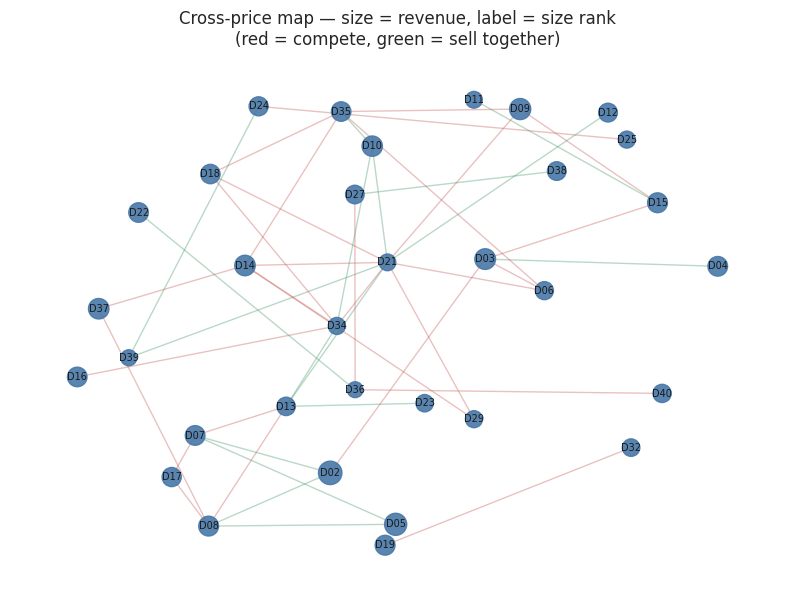

,id,format,pack,uom,count,revenue_m,links
0,D02,TABLETS WITH SOLUBLE FILM,42,CT,1,31.6,3
1,D05,TABLETS WITH SOLUBLE FILM,51,CT,1,23.3,2
2,D09,TABLETS WITH SOLUBLE FILM,59,CT,1,18.3,3
3,D03,TABLETS WITH SOLUBLE FILM,25,CT,1,16.4,4
4,D14,TABLETS WITH SOLUBLE FILM,74,CT,1,15.5,5
5,D37,TABLETS WITH SOLUBLE FILM,100,CT,1,15.4,2
6,D10,TABLETS WITH SOLUBLE FILM,42,CT,1,14.8,3
7,D15,TABLETS WITH SOLUBLE FILM,70,CT,1,13.0,3
8,D19,TABLETS WITH SOLUBLE FILM,72,CT,1,13.0,1
9,D08,TABLETS WITH SOLUBLE FILM,32,CT,1,12.8,5


,a,b,effect,p
0,D13,D23,-1.767,0.0
1,D21,D29,1.331,0.0
2,D03,D04,-0.902,0.0
3,D18,D21,0.869,0.0
4,D10,D35,-0.848,0.0
5,D18,D35,0.847,0.0
6,D09,D35,0.820,0.0
7,D14,D37,0.817,0.0


In [31]:
rank = weekly[weekly.rgm_ppg.isin(top40)].groupby("rgm_ppg").units.sum().sort_values(ascending=False)
short_id = {p: f"D{i+1:02d}" for i, p in enumerate(rank.index)}
info = (sales[sales.rgm_ppg.isin(top40)].groupby("rgm_ppg")
        .agg(pack=("product_unit_size", "first"), uom=("uom", "first"),
             count=("product_pack_count", "first"),
             revenue_m=("total_sales", lambda s: s.sum() / 1e6)))
info["format"] = info.index.map(raw.groupby("rgm_ppg").attribute_1.first())
info["id"] = info.index.map(short_id)

pos = nx.spring_layout(G, seed=RNG, k=0.9)
fig, ax = plt.subplots(figsize=(10, 7))
edge_col = ["#c0504d" if G[u][v]["sign"] > 0 else "#3a915f" for u, v in G.edges]
nx.draw_networkx_edges(G, pos, alpha=0.35, edge_color=edge_col, ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=[60 + 40 * np.sqrt(info.loc[n, "revenue_m"]) for n in G.nodes],
                       node_color="#4878a8", alpha=0.9, ax=ax)
nx.draw_networkx_labels(G, pos, labels={n: short_id[n] for n in G.nodes}, font_size=7, ax=ax)
ax.set_title("Cross-price map — size = revenue, label = size rank\n"
             "(red = compete, green = sell together)")
ax.axis("off")
save_and_show(fig, "cross_price_network")

node_table = (info.loc[list(G.nodes)]
              .assign(links=lambda d: d.index.map(dict(G.degree)))
              .sort_values("revenue_m", ascending=False)
              [["id", "format", "pack", "uom", "count", "revenue_m", "links"]]
              .round(1).reset_index(drop=True))
display(node_table.head(12))
save_table(node_table, "cross_price_node_lookup")

top_links = links.reindex(links.effect.abs().sort_values(ascending=False).index).head(8).copy()
top_links["a"], top_links["b"] = top_links.product_a.map(short_id), top_links.product_b.map(short_id)
display(top_links[["a", "b", "effect", "p"]].round(3).reset_index(drop=True))

In [32]:
# the same 45 links, counted by which groups the two products belong to
gname = features.set_index("rgm_ppg").group_name
il = links.assign(ga=links.product_a.map(gname), gb=links.product_b.map(gname),
                  kind=np.where(links.effect > 0, "compete", "sell together"))
il["group_pair"] = [" <-> ".join(sorted([a, b])) for a, b in zip(il.ga, il.gb)]
display(il.groupby(["group_pair", "kind"]).size().unstack(fill_value=0))

kind,compete,sell together
group_pair,,
Promo leaders <-> Promo leaders,7,5
Promo leaders <-> Shrinking shelf,0,2
Promo leaders <-> Steady core,9,7
Shrinking shelf <-> Shrinking shelf,2,0
Steady core <-> Steady core,10,3


Most competitive pressure sits inside and between the two big-seller groups.

### 5.5 The retailer lens

This is deliberately a market-level segmentation — one behavioural map across all six retailers. Two checks on whether that scope hides anything:

In [33]:
order = sales.groupby("retailer_nm").total_sales.sum().sort_values(ascending=False).index
R = {r: f"R{i+1}" for i, r in enumerate(order)}
sr = sales.assign(R=sales.retailer_nm.map(R))
desc = (sr.groupby("R").agg(revenue_m=("total_sales", lambda s: s.sum() / 1e6),
                            products=("rgm_ppg", "nunique"),
                            median_shelf=("acv_pct", "median"),
                            avg_promo_acv=("any_promo_acv_pct", "mean")))
desc["promo_rev_share"] = (sr.groupby("R").any_promo_amt.sum() / sr.groupby("R").total_sales.sum())
desc = desc.sort_values("revenue_m", ascending=False).round(2)
desc.insert(0, "retailer_nm", [f"{r[:14]}..." for code in desc.index
                               for r, c in R.items() if c == code])
display(desc)
full_map = pd.DataFrame({"R": list(R.values()), "retailer_nm": list(R.keys())})
save_table(desc.reset_index().drop(columns="retailer_nm").merge(full_map, on="R"),
           "retailer_profiles")

odd = desc.median_shelf.idxmin()
odd_raw = [r for r, code in R.items() if code == odd][0]
tail_view = features.iloc[idx].assign(sub=sub_labels)
tail_sub = tail_view.groupby("sub").shelf_presence.mean().idxmin()
tail_ppgs = tail_view[tail_view["sub"] == tail_sub].rgm_ppg
per_prod = sales.groupby("rgm_ppg").retailer_nm.unique()
only_odd = per_prod.loc[tail_ppgs].apply(lambda rs: set(rs) == {odd_raw}).mean()
print(f"{odd}: {desc.loc[odd, 'products']:.0f} products at median {desc.loc[odd, 'median_shelf']:.1f}% ACV "
      f"(other retailers: median {sales[sales.retailer_nm != odd_raw].acv_pct.median():.0f}%)")
print(f"micro-tail layer: {only_odd:.0%} of its products are sold ONLY in {odd}")

,retailer_nm,revenue_m,products,median_shelf,avg_promo_acv,promo_rev_share
R,,,,,,
R1,HASH_7B58EB7D...,290.45,113,65.80,22.46,0.48
R2,HASH_EA52C362...,200.28,113,66.77,17.17,0.41
R3,HASH_FE494EA4...,180.97,268,1.35,0.92,0.40
R4,HASH_86AFA19D...,95.27,120,60.35,18.99,0.42
R5,HASH_E5E16C6D...,75.76,104,75.84,27.99,0.55
R6,HASH_4456A3C8...,74.72,112,62.15,19.46,0.46


R3: 268 products at median 1.4% ACV (other retailers: median 67%)
micro-tail layer: 81% of its products are sold ONLY in R3


Two takeaways. First, retailers differ in the way you'd expect: the bigger the retailer, the
more promo activity and the larger the share of revenue sold on deal. So promo calendars are
a decision to make per retailer, even though the product map is shared. Second, R3 is an
outlier. It carries hundreds of products at around 1% ACV while every other retailer sits
near 60%. What R3 actually is goes on the question list for the data provider.

Why not one model per retailer? Each retailer carries only around 110 products, with far less
history each. That is too little data, and when I tried it anyway the results were unstable.
The better setup is one shared map built on all the data, then checking how each product
behaves within each retailer. A product that acts like a Promo leader in R1 but like a Steady
core product in R4 is not a modelling error. It is a finding: treat that product differently
in those two retailers.

## 6. Final Results & Next Steps

**Results.** 353 products fall into 3 groups by how they sell. **Promo leaders** (58 products,
41% of revenue): premium products, promoted heavily, and their promo weeks really do sell far
more than their quiet weeks. **Steady core** (234 products, 49%): low drama. It splits further
into 86 big steady sellers, 33 mid-sized products that promote occasionally, and a long tail
of 115 barely-stocked products. **Shrinking shelf** (61 products, 10%): steadily disappearing
from stores, even though the stores that still carry them sell them fine. The groups pass
their robustness checks, scoring 0.96 on resampling against a pass mark of 0.6 that was set in
advance. On top of the groups: 45 strict compete or sell-together links among the top
detergents, and a coverage grid showing which price-tier and format combinations the portfolio
barely covers.

**What I would do with it.** Most promotion money sits in the Promo leaders, so the first job
is measuring whether those promotions actually create sales rather than just shifting them.
The Shrinking-shelf group needs a keep-or-drop decision per product, starting with the
question of who decided to pull them from shelves. The 115-product tail turns out to be mostly
one retailer's exclusive assortment (R3), so it is really a question of whether we want to be
in that channel, not a delisting list. Leave the steady backbone alone.

**Open questions**, and the cheapest way to improve everything above: what are the rows priced
under 10p (and honestly, under 50p)? What does `total_volume` actually count? When a product's
shelf presence drops, was that our decision or the retailer's? And what is retailer R3, given
it operates on a completely different distribution scale?

**Next steps, in order of value:**
1. A baseline model for the Promo leaders: what would each week have sold without the
   promotion? That turns "promo weeks sell more" into "promotions added X units".
2. Break promo response down by type: price cut vs in-store display vs leaflet. The columns
   exist and are unused so far.
3. Refresh the groups quarterly and track which products move between them. The market
   measurably changed over these 3 years, with promo behaviour drifting 6.2 points on average.
4. Check the thin coverage cells against real consumer demand before calling them
   opportunities.
5. Score each product's behaviour per retailer against the shared groups. A product that
   behaves differently in different retailers is a retailer strategy finding.
6. Pressure-test the strongest compete and sell-together links using the natural experiments
   the promo calendar provides.

In [34]:
save_table(features.groupby("group_name")[FEATURES].mean().round(3).reset_index(), "group_profiles")
print("files written by this run:")
for path in written: print(" ", path)

files written by this run:
  docs/img/price_distribution.png
  docs/img/pareto_revenue.png
  docs/img/category_decomposition.png
  docs/img/feature_correlations.png
  docs/img/k_selection_scores.png
  docs/img/silhouette_diagram.png
  docs/img/clusters_overview.png
  docs/img/group_profiles.png
  docs/img/group_composition.png
  output/product_groups.csv
  output/suggestions.csv
  output/biggest_group_split.csv
  docs/img/portfolio_coverage.png
  docs/img/promo_drift.png
  output/cross_price_links.csv
  docs/img/cross_price_network.png
  output/cross_price_node_lookup.csv
  output/retailer_profiles.csv
  output/group_profiles.csv
